# init

In [ ]:
import os
import sys
import copy
import glob
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import pickle
from scipy import stats
import importlib
import time
import tifffile as tf
import shutil
from matplotlib.backends.backend_pdf import PdfPages
import json

#Some Figure Preferences
plt.rcParams['font.family']           = 'sans-serif'
plt.rcParams['font.sans-serif']       = ['Arial']
plt.rcParams['pdf.fonttype']          = 42       # embed fonts in PDF (Type 42)
plt.rcParams['axes.unicode_minus']    = False    # use ASCII minus sign
plt.rcParams['mathtext.default']      = 'regular'

#IMPORTANT two options for setting paths here:
#OPTION 1: Automatically determine the parent directory of the notebook's directory
try:
    import ipynbname
    NOTEBOOK_PATH = ipynbname.path()
    PARENT_DIR = NOTEBOOK_PATH.parent.parent  # parent of the notebook's directory
    DATA_DIR = os.path.join(PARENT_DIR, "Data")
    print("NOTEBOOK_PATH: " + str(NOTEBOOK_PATH))
except:
    print("UNABLE TO DETERMINE CURRENT SCRIPT LOCAITON PLEASE PROVIDE PATHS MANUALLY")

#OPTION 2: Manually set PARENT_DIR and DATA_DIR if needed
# PARENT_DIR = ".../Scheib_2026/"
# DATA_DIR = ".../Scheib_2026/Data/"

# DATA_DIR = os.path.join(PARENT_DIR,'data')
FIG_EXPORT_DIR = os.path.join(PARENT_DIR, "figurePanels", "Fig3")
PDF_export_active = False
if PDF_export_active:
    os.makedirs(FIG_EXPORT_DIR, exist_ok=True)

print("PARENT_DIR:     " + str(PARENT_DIR))
print("DATA_DIR:       " + str(DATA_DIR))
print("FIG_EXPORT_DIR: " + str(FIG_EXPORT_DIR))

#IMPORTANT: The following class and function are used to conditionally save figures to PDF based on the PDF_export_active flag. 
#           If PDF_export_active is True, figures will be saved to the specified path; if False, the savefig calls will be ignored.
class _NoPdf:
    """Null stand-in for PdfPages: accepts savefig calls and writes nothing."""
    def __enter__(self):        return self
    def __exit__(self, *exc):   return False
    def savefig(self, *args, **kwargs): pass

def maybe_pdf(path, active=None):
    active = PDF_export_active if active is None else active
    return PdfPages(path) if active else _NoPdf()

#OPTIONAL Load from specific directory if needed (uncomment the following lines)
if os.path.exists(os.path.join(NOTEBOOK_PATH, "js_manuscript_final.py")):
    print('FOUND js_manuscript_final.py')
    path = os.path.join(NOTEBOOK_PATH, "js_manuscript_final.py")
    spec = importlib.util.spec_from_file_location("jsm", path)
    jsm = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(jsm)
    print(jsm.__file__)
else:
    #IMPORTANT Load the manuscript functions from PYTHONPATH
    import js_manuscript_final as jsm
    
#OPTIONAL Reload the module to ensure the latest version is used
%load_ext autoreload
%autoreload 2

NOTEBOOK_PATH: /home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR/Fig3.ipynb
PARENT_DIR:     /home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR
DATA_DIR:       /export/general/pooledData/Jackson/repo_data/
FIG_EXPORT_DIR: /home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR/figurePanels/Fig3


In [2]:
savePath = os.path.join(DATA_DIR,'traceAlignments','fig3')  # existing directory to write the part files into
saveName = 'fig3_alignments'   # base name; '_meta' / '_<key>_<ROI_type>_<score>' suffixes are appended
extension = '.pkl'                 # '.pkl' | '.p'
verbose = True
ROI_type_keys = None               # None -> all ROI types; or list, e.g. ['dendrites','somas']
ROI_scores = None                  # None -> all scores; or list, e.g. [1]
big_keys = None                    # None -> every big key saved; [] -> metadata only
clusterList = None                 # None/[] -> all clusters; or list of cluster indices
trialGroupings = None                 # None -> all trial groupings; or list of trial grouping indices
ROI_clustering, cueInfo = jsm.load_ROI_clustering_reduced_split(
    savePath, saveName, ROI_type_keys=ROI_type_keys, ROI_scores=ROI_scores, big_keys=big_keys, clusterList=clusterList, trialGroupings=trialGroupings, extension=extension, verbose=verbose)


load_ROI_clustering_reduced_split: savePath='/export/general/pooledData/Jackson/repo_data/traceAlignments/fig3' saveName='fig3_alignments' ROI_type_keys=None ROI_scores=None big_keys=None clusterList=None trialGroupings=None
  + loaded fig3_alignments_meta.pkl  (0.007 GB)
  = cueInfo: loaded from metadata file
  + loaded fig3_alignments_clusters_dendrites_1_byPrePost_byTtype_c0.pkl  (0.018 GB)
  + loaded fig3_alignments_clusters_dendrites_1_byPrePost_byTtype_c1.pkl  (0.056 GB)
  + loaded fig3_alignments_clusters_dendrites_1_byPrePost_byTtype_c2.pkl  (0.032 GB)
  + loaded fig3_alignments_clusters_dendrites_1_byPrePost_byTtype_c3.pkl  (0.015 GB)
  + loaded fig3_alignments_clusters_dendrites_1_byPrePost_byTtype_c4.pkl  (0.056 GB)
  + loaded fig3_alignments_clusters_dendrites_1_byPrePost_byTtype_c5.pkl  (0.038 GB)
  + loaded fig3_alignments_clusters_dendrites_1_byPrePost_byTtype_c6.pkl  (0.005 GB)
  + loaded fig3_alignments_clusters_somas_1_byPrePost_byTtype_c0.pkl  (0.019 GB)
  + loaded f

In [3]:
# comments indented under a '> only if ...' marker = used only when that other arg is active
# This is the only cell a repo-only rebuild of the figure needs — no pooled dataset, no
# sled_reImport_aligned_trace_data. The repo-facing notebooks (e.g. Fig3.ipynb) call the identical
# function as jsm.load_all_grouped_aligned_traces_split with the same arguments.
savePath = os.path.join(DATA_DIR,'examples','fig3_indiv_examples')  # directory holding the '_meta' and part files
saveName = 'fig3_indiv_examples'   # same base name passed to save_all_grouped_aligned_traces_split
groups = None                      # None -> every group saved; or list, e.g. ['goCue']
align_datas = None                 # None -> every align_data saved; or list, e.g. ['allTC_dffbc_decon_sp_events_MatchDx2Sx1']
anms = None                        # None -> every animal saved; or list of animal IDs
ROI_type_keys = None               # None -> all ROI types; or list, e.g. ['dendrites','somas']
ROI_scores = None                  # None -> all scores; or list, e.g. [1]
ROI_idxs = None                    # None -> all example ROIs; or list of ROI indices to keep
trace_types = None                 # None -> every trace_type saved; or list of trace_types to keep
extension = '.pkl'              # '.pkl.gz' | '.pkl.xz' | '.pkl.bz2' | '.pkl'  (extension used when the files were written)
restore_float_dtype = 'float32'    # None -> keep the stored dtype; or 'float32' to cast float16 traces back up
verbose = True                     # True | False  (prints each part file loaded)
all_grouped_aligned_traces_repo, cueInfo_repo, summaryInfo_repo = jsm.load_all_grouped_aligned_traces_split(
    savePath, saveName, groups=groups, align_datas=align_datas, anms=anms, ROI_type_keys=ROI_type_keys, 
    ROI_scores=ROI_scores, ROI_idxs=ROI_idxs, trace_types=trace_types, extension=extension, restore_float_dtype=restore_float_dtype, verbose=verbose)

# The trace_types actually present in the loaded repo data. The re-plot cell below pins
# figParams['trialGrouping'] to this, so what gets plotted can never drift from what was exported.
repo_trace_types = []
for g in all_grouped_aligned_traces_repo:
    for ad in all_grouped_aligned_traces_repo[g]['grouped_aligned_traces']:
        traces = all_grouped_aligned_traces_repo[g]['grouped_aligned_traces'][ad].get('aligned_traces',{})
        for a in traces:
            for rt in traces[a]:
                for sc in traces[a][rt]:
                    for ri in traces[a][rt][sc]:
                        for t in traces[a][rt][sc][ri]:
                            if t not in repo_trace_types:
                                repo_trace_types.append(t)
# 'bySess_byTtype' only rides along as session support, so it is not a trace_type to plot on its own.
# These are STORED branch names: a figure trace_type of 'preShiftOnly_byTtype' reads 'byPrePost_byTtype'.
repo_trace_types = [t for t in repo_trace_types if t != 'bySess_byTtype'] or repo_trace_types
print(f"trace_types (stored branches) available in the repo data: {repo_trace_types}")

load_all_grouped_aligned_traces_split: savePath='/export/general/pooledData/Jackson/repo_data/examples/fig3_indiv_examples' saveName='fig3_indiv_examples' groups=None align_datas=None anms=None ROI_type_keys=None ROI_scores=None ROI_idxs=None trace_types=None
  + loaded fig3_indiv_examples_meta.pkl  (3.09 MB)
  = cueInfo: loaded from metadata file | summaryInfo: loaded from metadata file
  + loaded fig3_indiv_examples_traces_trialStart_allTC_dffbc_decon_sp_events_MatchDx2Sx1_B00002213982_dendrites_1_ROI38.pkl  (0.37 MB)
  + loaded fig3_indiv_examples_traces_trialStart_allTC_dffbc_decon_sp_events_MatchDx2Sx1_B00002214001_somas_1_ROI33.pkl  (0.6 MB)
  = ['trialStart']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['B00002213982']['dendrites'][1][38]: trace_types ['byPrePost_byTtype', 'bySess_byTtype']
  = ['trialStart']['allTC_dffbc_decon_sp_events_MatchDx2Sx1']['B00002214001']['somas'][1][33]: trace_types ['byPrePost_byTtype', 'bySess_byTtype']
trace_types (stored branches) available in the

# <font size="5">Load the exported example ROIs back out of the repo files

  Path: /export/general/pooledData/Jackson/repo_data/examples/fig3_indiv_examples
  File: Fig3_dend_example_NMFs.pkl
  FileSize:      0.02 GB (0.02 GiB)
  Last Modified: 2026-08-12 15:30:28.764069
  Loading Fig3_dend_example_NMFs.pkl from /export/general/pooledData/Jackson/repo_data/examples/fig3_indiv_examples...Finished!
  Loading Took a total of : 0.0 min


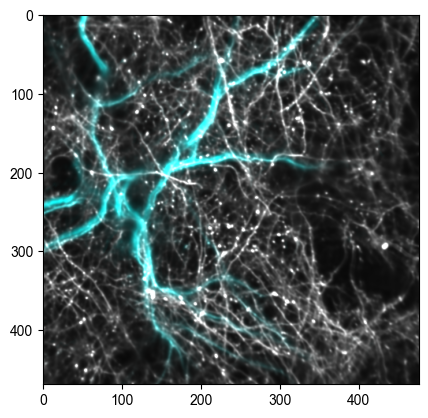

In [4]:
meanProj_color = (1,1,1)
meanProj_vmin = 0
meanProj_vmax = 10
NMF_color = (0,.75,.75)
NMF_color = (0,1,1)
NMF_vmin = 0
NMF_vmax = 2000
mask_vmin = 0
mask_vmax = 1
colorScalar = 1000

example_dend_ROI_imgs = jsm.unpickler(os.path.join(DATA_DIR,'examples','fig3_indiv_examples'), 'Fig3_dend_example_NMFs' , extension='.pkl', verbose=True)
example_dend_ROI_imgs['ROI_colors'] = [NMF_color]
tempCmap,_,_=jsm.generate_cmap(meanProj_color,colorScalar)
example_dend_ROI_imgs['meanProj_RGB']=jsm.convert2RGB(example_dend_ROI_imgs['meanProj'],\
        meanProj_vmin,meanProj_vmax,tempCmap,colorScalar)
example_dend_ROI_imgs['meanProj_RGB'] = example_dend_ROI_imgs['meanProj_RGB'][:,:,0:3]
example_dend_ROI_imgs['meanProj_RGB_crop']=jsm.convert2RGB(example_dend_ROI_imgs['meanProj_crop'],\
        meanProj_vmin,meanProj_vmax,tempCmap,colorScalar)
example_dend_ROI_imgs['meanProj_RGB_crop'] = example_dend_ROI_imgs['meanProj_RGB_crop'][:,:,0:3]

tempCmap,_,_=jsm.generate_cmap(example_dend_ROI_imgs['ROI_colors'][0],colorScalar)
example_dend_ROI_imgs['ROI_NMF_RGB']=jsm.convert2RGB(example_dend_ROI_imgs['ROI_NMF'],\
        NMF_vmin,NMF_vmax,tempCmap,colorScalar)
example_dend_ROI_imgs['ROI_NMF_RGB'] = example_dend_ROI_imgs['ROI_NMF_RGB'][:,:,0:3]
example_dend_ROI_imgs['ROI_NMF_RGB_crop']=jsm.convert2RGB(example_dend_ROI_imgs['ROI_NMF_crop'],\
        NMF_vmin,NMF_vmax,tempCmap,colorScalar)
example_dend_ROI_imgs['ROI_NMF_RGB_crop'] = example_dend_ROI_imgs['ROI_NMF_RGB_crop'][:,:,0:3]
example_dend_ROI_imgs['ROI_mask_RGB']=jsm.convert2RGB(example_dend_ROI_imgs['ROI_mask'],\
        mask_vmin,mask_vmax,tempCmap,colorScalar)
example_dend_ROI_imgs['ROI_mask_RGB'] = example_dend_ROI_imgs['ROI_mask_RGB'][:,:,0:3]
example_dend_ROI_imgs['ROI_mask_RGB_crop']=jsm.convert2RGB(example_dend_ROI_imgs['ROI_mask_crop'],\
        mask_vmin,mask_vmax,tempCmap,colorScalar)
example_dend_ROI_imgs['ROI_mask_RGB_crop'] = example_dend_ROI_imgs['ROI_mask_RGB_crop'][:,:,0:3]

example_dend_ROI_imgs['meanProj_NMF_merge_RGB'] = example_dend_ROI_imgs['meanProj_RGB'] + example_dend_ROI_imgs['ROI_NMF_RGB']
example_dend_ROI_imgs['meanProj_NMF_merge_RGB'][example_dend_ROI_imgs['meanProj_NMF_merge_RGB']>1] = 1
example_dend_ROI_imgs['meanProj_NMF_merge_RGB_crop'] = example_dend_ROI_imgs['meanProj_RGB_crop'] + example_dend_ROI_imgs['ROI_NMF_RGB_crop']
example_dend_ROI_imgs['meanProj_NMF_merge_RGB_crop'][example_dend_ROI_imgs['meanProj_NMF_merge_RGB_crop']>1] = 1
plt.figure()
plt.imshow(example_dend_ROI_imgs['meanProj_NMF_merge_RGB_crop'])


  Path: /export/general/pooledData/Jackson/repo_data/examples/fig3_indiv_examples
  File: Fig3_soma_example_NMFs.pkl
  FileSize:      0.0 GB (0.0 GiB)
  Last Modified: 2026-08-12 15:30:38.047068
  Loading Fig3_soma_example_NMFs.pkl from /export/general/pooledData/Jackson/repo_data/examples/fig3_indiv_examples...Finished!
  Loading Took a total of : 0.0 min


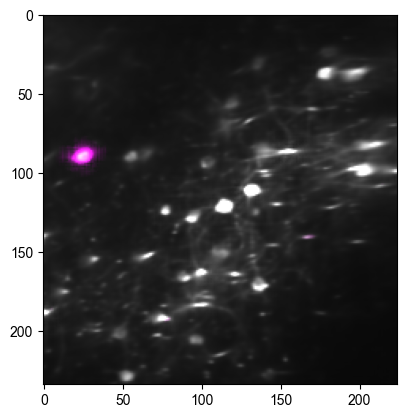

In [5]:
meanProj_color = (1,1,1)
meanProj_vmin = 0
meanProj_vmax = 10
NMF_color = (1,0,1)
NMF_vmin = 0
NMF_vmax = 2000
mask_vmin = 0
mask_vmax = 1
colorScalar = 1000

example_soma_ROI_imgs = jsm.unpickler(os.path.join(DATA_DIR,'examples','fig3_indiv_examples'), 'Fig3_soma_example_NMFs' , extension='.pkl', verbose=True)
example_soma_ROI_imgs['ROI_colors'] = [NMF_color]
tempCmap,_,_=jsm.generate_cmap(meanProj_color,colorScalar)
example_soma_ROI_imgs['meanProj_RGB']=jsm.convert2RGB(example_soma_ROI_imgs['meanProj'],\
        meanProj_vmin,meanProj_vmax,tempCmap,colorScalar)
example_soma_ROI_imgs['meanProj_RGB'] = example_soma_ROI_imgs['meanProj_RGB'][:,:,0:3]
example_soma_ROI_imgs['meanProj_RGB_crop']=jsm.convert2RGB(example_soma_ROI_imgs['meanProj_crop'],\
        meanProj_vmin,meanProj_vmax,tempCmap,colorScalar)
example_soma_ROI_imgs['meanProj_RGB_crop'] = example_soma_ROI_imgs['meanProj_RGB_crop'][:,:,0:3]

tempCmap,_,_=jsm.generate_cmap(example_soma_ROI_imgs['ROI_colors'][0],colorScalar)
example_soma_ROI_imgs['ROI_NMF_RGB']=jsm.convert2RGB(example_soma_ROI_imgs['ROI_NMF'],\
        NMF_vmin,NMF_vmax,tempCmap,colorScalar)
example_soma_ROI_imgs['ROI_NMF_RGB'] = example_soma_ROI_imgs['ROI_NMF_RGB'][:,:,0:3]
example_soma_ROI_imgs['ROI_NMF_RGB_crop']=jsm.convert2RGB(example_soma_ROI_imgs['ROI_NMF_crop'],\
        NMF_vmin,NMF_vmax,tempCmap,colorScalar)
example_soma_ROI_imgs['ROI_NMF_RGB_crop'] = example_soma_ROI_imgs['ROI_NMF_RGB_crop'][:,:,0:3]
example_soma_ROI_imgs['ROI_mask_RGB']=jsm.convert2RGB(example_soma_ROI_imgs['ROI_mask'],\
        mask_vmin,mask_vmax,tempCmap,colorScalar)
example_soma_ROI_imgs['ROI_mask_RGB'] = example_soma_ROI_imgs['ROI_mask_RGB'][:,:,0:3]
example_soma_ROI_imgs['ROI_mask_RGB_crop']=jsm.convert2RGB(example_soma_ROI_imgs['ROI_mask_crop'],\
        mask_vmin,mask_vmax,tempCmap,colorScalar)
example_soma_ROI_imgs['ROI_mask_RGB_crop'] = example_soma_ROI_imgs['ROI_mask_RGB_crop'][:,:,0:3]

example_soma_ROI_imgs['meanProj_NMF_merge_RGB'] = example_soma_ROI_imgs['meanProj_RGB'] + example_soma_ROI_imgs['ROI_NMF_RGB']
example_soma_ROI_imgs['meanProj_NMF_merge_RGB'][example_soma_ROI_imgs['meanProj_NMF_merge_RGB']>1] = 1
example_soma_ROI_imgs['meanProj_NMF_merge_RGB_crop'] = example_soma_ROI_imgs['meanProj_RGB_crop'] + example_soma_ROI_imgs['ROI_NMF_RGB_crop']
example_soma_ROI_imgs['meanProj_NMF_merge_RGB_crop'][example_soma_ROI_imgs['meanProj_NMF_merge_RGB_crop']>1] = 1
plt.figure()
plt.imshow(example_soma_ROI_imgs['meanProj_NMF_merge_RGB_crop'])


In [6]:
# comments indented under a '> only if ...' marker = used only when that other arg is active
# Small manifest of the per-example scalars trial_alignments_byROI_pages needs beyond the traces
# themselves (identifying indices + cosmetic page/cluster label text) — written by the export cell in
# Fig3_indiv_examples.ipynb, loaded here so this repo-only notebook never needs ROI_clustering (a
# clustering-run object that never ships to the repo).
import json
manifest_path = os.path.join(savePath, saveName+'_ROI_manifest.json')  # written by the export cell in Fig3_indiv_examples.ipynb
with open(manifest_path,'r') as f:
    ROI_manifest = json.load(f)
print(f"Loaded {len(ROI_manifest)} example ROI(s) from {manifest_path}")

Loaded 2 example ROI(s) from /export/general/pooledData/Jackson/repo_data/examples/fig3_indiv_examples/fig3_indiv_examples_ROI_manifest.json


Zoom mode activated: 6sZOOM
          xlim_zoom: {'trialStart': [-0.4, 6.2], 'goCue': [-3.1, 3.1], 'cTimes': [-3.1, 3.1], 'postContLick1': [-3.1, 3.1]}
        xticks_zoom: {'trialStart': [0, 1, 2, 3, 4, 5, 6], 'goCue': [-3, -2, -1, 0, 1, 2, 3], 'cTimes': [-3, -2, -1, 0, 1, 2, 3], 'postContLick1': [-3, -2, -1, 0, 1, 2, 3]}
FIG_EXPORT_DIR = /home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR/figurePanels/Fig3
figName = Fig3_examples_fromRepoData.pdf
Adding anmIdx 16 B00002213982 dendrites ROI_score 1 ROI0 ROI_idx 38 pg279...nRows: 3, nCols: 2, nPlots 1, figSize: (6.8, 3)
Finished!


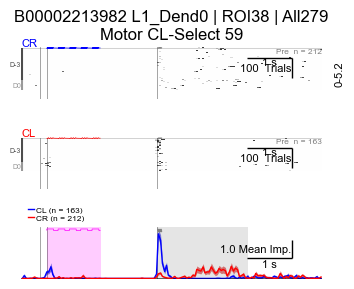

Adding anmIdx 21 B00002214001 somas ROI_score 1 ROI33 ROI_idx 33 pg526...nRows: 3, nCols: 2, nPlots 1, figSize: (6.8, 3)
Finished!


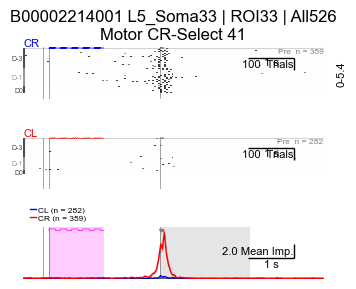

In [7]:
figParams = {}
# Same panels as the Fig3_examples.pdf cell above, but driven entirely off the loaded repo
# data (all_grouped_aligned_traces_repo / summaryInfo_repo) — compare the two PDFs to confirm the
# export round-tripped. Loops over ROI_manifest (loaded above) instead of indexing ROI_clustering,
# so this repo-only notebook never needs the clustering-run object.
figParams['cueInfo'] = cueInfo_repo
# keep the display mode the examples cell set ('preShiftOnly_byTtype' etc. resolve to the stored
# 'byPrePost_byTtype' branch); only fall back if the repo data does not hold what it reads
# if jsm.resolve_align_trace_type(figParams['trialGrouping'])[0] not in repo_trace_types:
# print(f"figParams['trialGrouping'] {figParams['trialGrouping']!r} is not in the repo data "
#         f"{repo_trace_types}; falling back to {repo_trace_types[0]!r}")
figName = 'Fig3_examples_fromRepoData.pdf'
figParams['preview_figs'] = False
figParams['close_all_figs'] = False
saveFigs = PDF_export_active
verbose =True

group_label = 'AllTraceTypes_SDNorm'
group = 'trialStart'
group_labels = ['AllTraceTypes_SDNorm']
trialGroupings = ['preShiftOnly_byTtype']
trialGrouping_labels = ['PreShift']
plotSets = ["CLCR"]
figParams['export_align_data'] = ['allTC_dffbc_decon_sp_events_MatchDx2Sx1'] 
figParams['export_align_data_labels'] = ['sp_eventD2S1'] 

########################################################
figParams['plot_stat'] = 'summaryStats'
tg = 0
trialGrouping = trialGroupings[tg]
trialGrouping_label = trialGrouping_labels[0]
ps = plotSets[0]
a = 0
align_data = figParams['export_align_data'][a]

zoom_s = 6
figParams['align_data'] = align_data
figParams['align_data_label'] = figParams['export_align_data_labels'][a]
figParams['formatMode'] = 'vert'
figParams['examples_group'] = group
figParams['trialGrouping'] = trialGrouping
figParams['trial_group_label'] = trialGrouping_labels[tg]
figParams['horzCueLineOn'] = True
figParams['horzCuePlotScalar'] = 0.03
figParams['horzCueImScalar'] = 0.01
figParams['line_colors_right']=[[0,0,1],[0,0,0.5]]
figParams['line_colors_left']=[[1,0,0],[0.5,0,0]]
figParams['addSpacers'] = True
figParams['dayLabels'] = True
figParams['sess_cmap'] = 'tab10'
figParams['export_ROI_type_keys'] = ['dendrites','somas']                       # 'dendrites','somas'
figParams['export_ROI_scores'] = [1]                              # 1,-1,0
figParams['shiftDay_nTrials'] = 100
figParams['shiftTrial_color'] = (1,0,0)
figParams['shiftTrial_lineStyle'] = ':'
figParams['shiftTrial_lineWidth'] = 1
figParams['shiftTrial_alpha'] = 0.3
figParams['yTicksOn'] = False
figParams['match_trial_counts'] = True
figParams['match_trial_ticks'] = 50
figParams['minRepeats_forYLim'] = 40 #to contribute to max/min caCLs
figParams['plotScalar']=0
figParams['scale_font'] = 10
figParams['legendFontsize'] = 6
figParams['facecolors_generic']=[[1,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_right']=[[0,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_left']=[[1,0,0],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors']=[[1,0,1],[1,1,0.5],[0.5,0.5,0.5]]
figParams['patch_alpha'] = 0.2
figParams['alpha']=0.5
figParams['edgecolor']='none'
figParams['imshow_lineWidth'] = 0.5

aaronCmap = {}
aaronCmap['type'] = 'smooth_diverging'
aaronCmap['cmap2'] = "gray"
aaronCmap['cmap1'] = "inferno"
aaronCmap['cutoff'] = 0.85
aaronCmap['center_width'] = 0.3
aaronCmap['minVal'] = 0.5
aaronCmap['maxVal'] = 0.9

figParams['cmap'] = aaronCmap
figParams['nan_color'] = (0.3,0.3,0.3)
figParams['horzScalar'] = 10
figParams['horzScalar_im'] = 10
figParams['horzScalar_zoom'] = 10
figParams['horzScalar_im_zoom'] = 3.4
figParams['vertScalar'] = 3
figParams['vertScalar_im'] = 3
figParams['vertScalar_zoom'] = 3
figParams['vertScalar_im_zoom'] = 1
figParams['wspace'] = 0.03
figParams['hspace'] = 0.005

figParams['horz_scale']=1
figParams['horz_scale_label']=" s"
figParams['horz_scale_loc']='TL'
figParams['vert_scale_loc']='TL'

##############################
figParams['plot_scaleBar']={}
figParams['plot_scaleBar']['length_s'] = 1
figParams['plot_scaleBar']['corner']='BR'
figParams['plot_scaleBar']['height_per'] = 0.4
figParams['plot_scaleBar']['lw'] = 1
figParams['plot_scaleBar']['vertAdjust']=0.4
figParams['plot_scaleBar']['horzAdjust']=0.1
figParams['plot_scaleBar']['fontsize'] = 8
figParams['plot_scaleBar']['includeLabel'] = False
##############################
figParams['im_scaleBar']={}
figParams['im_scaleBar']['corner']='BR'
figParams['im_scaleBar']['height_per'] = 0.3
figParams['im_scaleBar']['vertUnit'] = ' Trials'
figParams['im_scaleBar']['horzUnit'] = 's'
figParams['im_scaleBar']['manual_height'] = 100
figParams['im_scaleBar']['lw'] = 1
figParams['im_scaleBar']['vertAdjust']=0.2
figParams['im_scaleBar']['horzAdjust']=0.1
figParams['im_scaleBar']['fontsize'] = 8
figParams['im_scaleBar']['includeLabel'] = False

##############################
figParams['nan_empty_trials'] = True
figParams['plot_error'] = True

figParams['plot_key_main'] = 'boot_mean'
figParams['plot_key_error_pos'] = 'boot_std' #'sem'
figParams['plot_key_error_neg'] = 'boot_std' #'sem'
figParams['plot_key_label'] = "Trial Bootstrap\nMean (STD)"
figParams['plot_label'] = "TrialBootMeanSTD"

figParams['imshow_lineColor'] = (0,0,0)
figParams['window_lineColor'] = (0,0.75,0.75)
figParams['nSpacers'] = 3
figParams['endSpacer'] = False
figParams['tickSpacing_fr'] = 50
figParams['colorScalar'] = 1000
##############################
figParams,zoom = jsm.zoom_lookup(zoom_s,figParams)
##############################
figParams['vertUpperPlotBuffer'] = 0.02
figParams['vertLowerPlotBuffer'] = 0.01
figParams['manual_plotLims'] = False
figParams['manual_imCont'] = False
figParams['highImCont'] = {}
figParams['lowImCont'] = {}
figParams['highNormImCont'] = {}
figParams['lowNormImCont'] = {}
figParams['highDeltaImCont'] = {}
figParams['highROIImCont'] = {}
figParams['lowROIImCont'] = {}
figParams[align_data] = {}
figParams[align_data]['highROIImCont'] = {}
figParams[align_data]['lowROIImCont'] = {}
figParams[align_data]['nan_empty_trials'] = False
figParams[align_data]['revert_mask'] = True
figParams[align_data]['maxPer'] = 100
figParams[align_data]['highROIImCont']['dendrites'] = 0.2
figParams[align_data]['lowROIImCont']['dendrites'] = 0
figParams[align_data]['highROIImCont']['somas'] = 0.1
figParams[align_data]['lowROIImCont']['somas'] = 0
figParams['highCont'] = 0.9
figParams['minPer'] = 0
figParams['lowCont'] = 1
figParams['highImCont']['dendrites'] = []
figParams['lowImCont']['dendrites'] = []
figParams['highNormImCont']['dendrites'] = []
figParams['lowNormImCont']['dendrites'] = []
figParams['highDeltaImCont']['dendrites'] = []
figParams['highImCont']['somas'] = []
figParams['lowImCont']['somas'] = []
figParams['highNormImCont']['somas'] = []
figParams['lowNormImCont']['somas'] = []
figParams['highDeltaImCont']['somas'] = []

figParams['highImCont']['dendrites'].append(0.005)
figParams['lowImCont']['dendrites'].append(0)
figParams['highNormImCont']['dendrites'].append(0.8)
figParams['lowNormImCont']['dendrites'].append(0)
figParams['highDeltaImCont']['dendrites'].append(0.1)
figParams['highImCont']['somas'].append(0.005)
figParams['lowImCont']['somas'].append(0)
figParams['highNormImCont']['somas'].append(0.8)
figParams['lowNormImCont']['somas'].append(0)
figParams['highDeltaImCont']['somas'].append(0.1)
figParams['expanding_lineColor'] = (0.5,0.5,0.5)
figParams['expanding_lineStyle'] = '-'
figParams['expanding_lineWidth'] = 1
figParams['expanding_lineAlpha'] = 0.5
figParams['expanding_lineColor'] = (0.5,1,0)

figParams['scaling_be'] = ['preShift','postShift']
if 'preShiftOnly' in trialGrouping:
    figParams['scaling_be'] = ['preShift']
if 'postShiftOnly' in trialGrouping:
    figParams['scaling_be'] = ['postShift']
figParams['export_ttypes'] = ['CR','CL'] 
figParams['export_ttype_colors'] = [(0,0,1),(1,0,0)]
figParams['scaling_ttypes'] = ['CL','CR']

figParams['autoScale_ttypes'] = figParams['scaling_ttypes']
figParams['autoScale_be_ttypes'] = figParams['scaling_ttypes']

figParams['nan_empty_trials'] = figParams[align_data]['nan_empty_trials']
figParams['revert_mask'] = figParams[align_data]['revert_mask']
figParams['maxPer'] = figParams[align_data]['maxPer']
figParams['highROIImCont'] = figParams[align_data]['highROIImCont']
figParams['lowROIImCont'] = figParams[align_data]['lowROIImCont']

figParams['constrained_layout'] = False
figParams['dayLabels'] = True
figParams['clean'] = True
figParams['facecolor'] = 'none'
# figParams['facecolor'] = (1,1,1)
figParams['yTicksOn']= False
figParams['legendLoc'] = 'lower left'
figParams['legendBboxToAnchor'] = (0, 1)


figParams['export_byPrePost_ttype_colors'] = {}
figParams['export_byPrePost_ttype_colors']['preShift'] = [(0.5,0,0),(0,0,0.5)]
figParams['export_byPrePost_ttype_colors']['postShift'] = [(1,0,0),(0,0,1)]
if 'ShiftOnly' in trialGrouping:
    figParams['addSpacers'] = False
    figParams['export_byPrePost_ttype_colors']['preShift'] = [(1,0,0),(0,0,1)]
    figParams['export_byPrePost_ttype_colors']['postShift'] = [(1,0,0),(0,0,1)]


print(f'FIG_EXPORT_DIR = {FIG_EXPORT_DIR}')
print(f'figName = {figName}')
with maybe_pdf(os.path.join(FIG_EXPORT_DIR,figName)) as pdf:
    for entry in ROI_manifest:
        pdf = jsm.trial_alignments_byROI_pages(pdf, summaryInfo_repo, \
            all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['traceAlignParams'],\
            all_grouped_aligned_traces_repo[figParams['examples_group']]['grouped_aligned_traces'][align_data]['aligned_traces'], \
            figParams, figParams['trialGrouping'], align_data, zoom, figParams['export_ttypes'], \
            entry['ROI_score'], entry['ROI_type_key'], entry['anmIdx'], entry['anm'], entry['ROI_idx'], \
            entry['page_count'], entry['cluster_label'], entry['cluster_idx'], saveFigs, verbose)
    # plt.show()

# <font size="5">Rasters for paper Fig 3

In [8]:
figParams  = {}
figSubDir = ""
batchID = 'Fig3'
#########################################################################################################################################################################################################

figParams['clean'] = True
figParams['batchID'] = batchID
figParams['group'] = 'trialStart'
figParams['trialGrouping'] = 'byPrePost_byTtype'   # 'allSess_byTtype', allSess_deltaTtypes 'byBehavEpoch_byTtype' byBehavEpoch_deltaTtypes
figParams['trialGrouping_behavior_epoch'] = 'preShift'                                  # 
ROI_score = 1
align_data = 'allTC_dffbc_decon_sp_events_MatchDx2Sx1'
align_data_short = copy.deepcopy(align_data)
align_data_short = align_data_short.replace("allTC_","")
figParams['export_align_data'] = [align_data] 
figParams['export_align_data_label'] = [align_data_short] 

zoom_s = 6
##############################
# CI = str(np.round(ROI_clustering['dendrites'][1]['CI']*100))
figParams['filt_trace_byROI'] = True
figParams['filt_trace_byROI_window'] = {}
figParams['filt_trace_byROI_window'][align_data] = {}
figParams['filt_trace_byROI_window'][align_data]['dendrites'] = 3
figParams['filt_trace_byROI_window'][align_data]['somas'] = 3

figParams['plot_figSummary_label'] = "CRCL"
figParams['export_ttypes'] = ['CR','CL'] 

figParams['plot_figSummary_label'] = "CLCR"
figParams['export_ttypes'] = ['CL','CR'] 


figParams['scaling_ttypes'] = ['CL','CR']  
figParams['scaling_be'] = ['preShift','postShift']

figParams['export_ROI_type_keys'] = ['dendrites','somas']
figParams['export_ROI_scores'] = [1]

figParams['ROI_aspects']=[0.5,0.5]
figParams['ROI_aspects']=['auto','auto']

figParams['page2_hscalar'] = 2.3
figParams['page2_vscalar'] = 1.2
figParams['page2_fontSize'] = 8

##############################
figParams['addSpacers'] = False
figParams['clusterGrid'] = False
figParams['addClusterLabels'] = True
figParams['imshow_ytick_verticalalignment'] = 'center'
figParams['imshow_ytick_horizontalalignment'] = 'right'
figParams['imshow_ytick_rotation'] = 0
##############################
figParams['scale_font'] = 16
# figParams['facecolors_generic']=[[0.4,0.4,0.4],[0.8,0.8,0.8],[0.6,0.6,0.6]]
figParams['facecolors_generic']=[[1,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_right']=[[0,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_left']=[[1,0,0],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors']=[[1,0,1],[1,1,0.5],[0.5,0.5,0.5]]
figParams['line_colors_right']=[[0,0,1],[0,0,0.5]]
figParams['line_colors_left']=[[1,0,0],[0.5,0,0]]
figParams['patch_alpha'] = 0.2
figParams['colorScalar'] = 1000
figParams['colorScalar'] = 1000
figParams['alpha']=0.5
figParams['edgecolor']='none'
figParams['imshow_lineWidth'] = 0.5
figParams['cmap'] = 'inferno'
# figParams['cmap'] = aaronCmap
figParams['imshow_lineColor'] = (1,1,1)
figParams['window_lineColor'] = (0,0.75,0.75)
figParams['tickSpacing_fr'] = 50
figParams['fillNaNs'] = True
figParams['ylim_adjust'] = [2,2]
##############################

figParams['horzCueLineOn'] = True
figParams['horzCuePlotScalar'] = 0.02
figParams['horzCueImScalar'] = 0.01
figParams['cueInfo'] = cueInfo

##############################
figParams['plot_scaleBar']={}
figParams['plot_scaleBar']['corner']='BR'
figParams['plot_scaleBar']['height_per'] = 0.2
figParams['plot_scaleBar']['lw'] = 1
figParams['plot_scaleBar']['vertAdjust']=0.75
figParams['plot_scaleBar']['horzAdjust']=0.1
figParams['plot_scaleBar']['fontsize'] = 6
figParams['plot_scaleBar']['includeLabel'] = False
##############################
figParams['im_scaleBar']={}
figParams['im_scaleBar']['corner']='BR'
figParams['im_scaleBar']['height_per'] = 0.4
figParams['im_scaleBar']['lw'] = 1
figParams['im_scaleBar']['vertAdjust']=0.5
figParams['im_scaleBar']['horzAdjust']=0.1
figParams['im_scaleBar']['fontsize'] = 6
figParams['im_scaleBar']['includeLabel'] = False
figParams['im_scaleBar']['vertUnit'] = 'Masks'
figParams['im_scaleBar']['horzUnit'] = 's'
##############################
figParams,zoom = jsm.zoom_lookup(zoom_s,figParams)
##############################
figParams['clustered_data'] = 'mean'  # 'mean', 'var'
#########################################################################################################################################################################################################
figParams['clustered_data'] = 'mean'  # 'mean', 'var'
##############################
figParams['nan_color'] = (0.3,0.3,0.3)
figParams['plot_data_label'] = 'allSess_mean'
figParams['imScalar'] = [0.9,0.9,0.8,0.8,0.8,0.8,0.8] # by export_align_data
figParams['imScalar_byROI'] = [0.7,0.7,0.6,0.6,0.6,0.6,0.6] # by export_align_data
##############################
        
figParams['plot_data'] = 'boot_mean'   # 'mean', 'med', 'std'
figParams['plot_data_label_full'] = "PreShift\nCluster Boot Mean"
figParams['plot_data_axis_label'] = 'PreShift\nCluster Bootstrap\nMean (STD)'
figParams['plot_data_axis_label1'] = 'PreShift\nCluster Bootstrap\nMean (STD)'
figParams['plot_data_error_pos'] = 'boot_std' #'sem'
figParams['plot_data_error_neg'] = 'boot_std' #'sem'
figParams['plot_data_error_pos1'] = 'boot_std' #'sem'
figParams['plot_data_error_neg1'] = 'boot_std' #'sem'


figParams['plot_stat'] = 'summaryStats' # summaryStats, summaryStats_ttype_norm, summaryStats_ROI_norm, summaryStats_noExcl, summaryStats_noExcl_ttype_norm, summaryStats_noExcl_ROI_norm
figParams['plot_stat_byROI'] = 'data'  # 'data', 'data_ROI_norm', 'data_ttype_norm'
figParams['plot_data_byROI_label_full'] = '\nPreShift Trial\nBootstrap Mean'
figParams['plot_data_byROI_label'] = 'preShift_Trial_Boot_Mean'
figParams['plot_data_byROI_axis_label'] = 'PreShift Trial\nBootstrap Mean'
figParams['plot_data_byROI'] = 'boot_mean'
figParams['plot_data_byROI_errors'] = True
figParams['plot_data_byROI_error_pos'] = 'boot_std'
figParams['plot_data_byROI_error_neg'] = 'boot_std'
##############################


Zoom mode activated: 6sZOOM
          xlim_zoom: {'trialStart': [-0.4, 6.2], 'goCue': [-3.1, 3.1], 'cTimes': [-3.1, 3.1], 'postContLick1': [-3.1, 3.1]}
        xticks_zoom: {'trialStart': [0, 1, 2, 3, 4, 5, 6], 'goCue': [-3, -2, -1, 0, 1, 2, 3], 'cTimes': [-3, -2, -1, 0, 1, 2, 3], 'postContLick1': [-3, -2, -1, 0, 1, 2, 3]}


Fig3_trialStart_preShift_dffbc_decon_sp_events_MatchDx2Sx1_Filt3_6sZOOM.pdf
figsize: (4.6, 1.2) nRows: 1 nCols: 2


/home/range6-raid17/kerlinlab/envs/Scheib2026_env/lib/python3.8/site-packages/numpy/lib/nanfunctions.py:1556: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


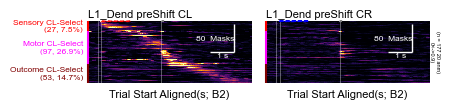

figsize: (4.6, 1.2) nRows: 1 nCols: 2


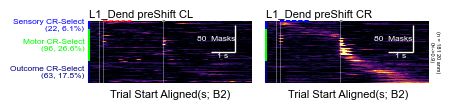

figsize: (4.6, 1.2) nRows: 1 nCols: 2


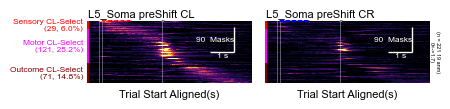

figsize: (4.6, 1.2) nRows: 1 nCols: 2


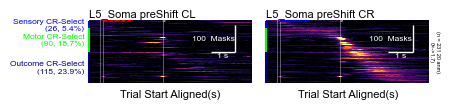

In [9]:
ROI_type_key = 'dendrites'
if figParams['filt_trace_byROI']:
    if align_data in figParams['filt_trace_byROI_window'].keys():
        if ROI_type_key in figParams['filt_trace_byROI_window'][align_data].keys():
            filtLabel = "_Filt"+str(figParams['filt_trace_byROI_window'][align_data][ROI_type_key])
        else:
            filtLabel = ""
    else:
        filtLabel = ""
else:
    filtLabel = ""
if zoom:
    zoomLabel = "_"+figParams['zoom_label']+".pdf"
else:
    zoomLabel = ""
figName = figParams['batchID']+"_"+figParams['group']+"_"+figParams['trialGrouping_behavior_epoch']+"_"+align_data_short+filtLabel+zoomLabel
print(figName)
##############################
figDir=os.path.join(FIG_EXPORT_DIR)
try:
    os.mkdir(figDir)
except:
    pass

with maybe_pdf(os.path.join(figDir,figName)) as pdf:
    for ROI_type_key in figParams['export_ROI_type_keys']:
        for ROI_score in figParams['export_ROI_scores']:
            if ROI_type_key == 'dendrites':
                figParams['manualContrastLimits'] = [0,0.9]
            else:
                figParams['manualContrastLimits'] = [0,1.7]
            
            figParams['clusterList'] = [0,1,2]
            fig,ax = jsm.aligned_ROI_cluster_trace_raster_fig(ROI_clustering,figParams,ROI_type_key,ROI_score,align_data,zoom)
            fig,ax=jsm.remove_all_clipping(fig,ax)
            if PDF_export_active:
                pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
            jsm.display_clean_subplots(fig,ax)
            figParams['clusterList'] = [3,4,5]
            fig,ax = jsm.aligned_ROI_cluster_trace_raster_fig(ROI_clustering,figParams,ROI_type_key,ROI_score,align_data,zoom)
            fig,ax=jsm.remove_all_clipping(fig,ax)
            if PDF_export_active:
                pdf.savefig(fig,bbox_inches='tight',pad_inches=0.05,dpi=600)  # saves the current figure into a pdf page
            jsm.display_clean_subplots(fig,ax)


# <font size="5">Licking Rasters for paper Fig 3

In [10]:
savePath = os.path.join(DATA_DIR,'traceAlignments','fig3_licking')  # existing directory to write the part files into
saveName = 'fig3_licking'   # base name; '_meta' / '_<key>_<ROI_type>_<score>' suffixes are appended
extension = '.pkl'                 # '.pkl' | '.p'
verbose = True
ROI_type_keys = None               # None -> all ROI types; or list, e.g. ['dendrites','somas']
ROI_scores = None                  # None -> all scores; or list, e.g. [1]
big_keys = None                    # None -> every big key saved; [] -> metadata only
clusterList = None                 # None/[] -> all clusters; or list of cluster indices
trialGroupings = None                 # None -> all trial groupings; or list of trial grouping indices
ROI_clustering, cueInfo = jsm.load_ROI_clustering_reduced_split(
    savePath, saveName, ROI_type_keys=ROI_type_keys, ROI_scores=ROI_scores, big_keys=big_keys, clusterList=clusterList, trialGroupings=trialGroupings, extension=extension, verbose=verbose)


load_ROI_clustering_reduced_split: savePath='/export/general/pooledData/Jackson/repo_data/traceAlignments/fig3_licking' saveName='fig3_licking' ROI_type_keys=None ROI_scores=None big_keys=None clusterList=None trialGroupings=None
  + loaded fig3_licking_meta.pkl  (0.007 GB)
  = cueInfo: loaded from metadata file
  + loaded fig3_licking_clusters_dendrites_licks_c0.pkl  (0.007 GB)
  + loaded fig3_licking_clusters_dendrites_licks_c1.pkl  (0.007 GB)
  + loaded fig3_licking_clusters_somas_licks_c0.pkl  (0.007 GB)
  + loaded fig3_licking_clusters_somas_licks_c1.pkl  (0.007 GB)
  = ['dendrites']['licks']: 32 keys, 2 clusters, trialGroupings ['byPrePost_byTtype']
  = ['somas']['licks']: 32 keys, 2 clusters, trialGroupings ['byPrePost_byTtype']


Zoom mode activated: 6sZOOM
          xlim_zoom: {'trialStart': [-0.4, 6.2], 'goCue': [-3.1, 3.1], 'cTimes': [-3.1, 3.1], 'postContLick1': [-3.1, 3.1]}
        xticks_zoom: {'trialStart': [0, 1, 2, 3, 4, 5, 6], 'goCue': [-3, -2, -1, 0, 1, 2, 3], 'cTimes': [-3, -2, -1, 0, 1, 2, 3], 'postContLick1': [-3, -2, -1, 0, 1, 2, 3]}
figDir /home/range6-raid17/kerlinlab/sled/sled-klab/manuscripts/Scheib2026/VOR/figurePanels/Fig3
Exporting: byPrePost_byTtype_trialStart_CLCR_OverlaySplit_FIG_LicksPerSec_MatchDx2Sx1_6sZOOM.pdfCollecting Overlay Info: 
Adding cg0 traseSetLeftLicks_preShift
Adding cg0 traseSetRightLicks_preShift
licks_per_s_Dx2_Sx1 dendrites licks im_minVal = 0.000000, im_maxVal = 9.286649
                                   im_minVal_cont = 0.000000, im_maxVal_cont = 8.822317
licks_per_s_Dx2_Sx1 somas licks im_minVal = 0.000000, im_maxVal = 9.128120
                                   im_minVal_cont = 0.000000, im_maxVal_cont = 8.671714
Generating figure with size (16, 0.6) nRows 2 nCo

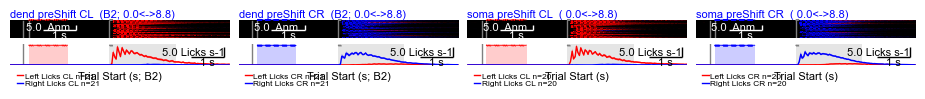

Finshed!


In [13]:
close_all_figs = False
batchID = 'Fig3_licking'
figSubDir = []
batchIDs = [0]
zooms = [6]
export_align_data = ['licks_per_s_Dx2_Sx1']
export_groups = ['trialStart']
setLabel ='CLCR_OverlaySplit_FIG'
figParams = {}
zoom_s = 6
####################################################################################################################################################################################
figParams['clean'] = True

figParams['scaling_ttypes'] = ['CL','CR','IR','MER']  
figParams['scaling_be'] = ['preShift','postShift']  
##############################
figParams['scale_font'] = 10
# figParams['facecolors_generic']=[[0.4,0.4,0.4],[0.8,0.8,0.8],[0.6,0.6,0.6]]
figParams['facecolors_generic']=[[1,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_right']=[[0,0,1],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors_left']=[[1,0,0],[1,1,0],[0.5,0.5,0.5]]
figParams['facecolors']=[[1,0,1],[1,1,0.5],[0.5,0.5,0.5]]
figParams['line_colors_right']=[[0,0,1],[0,0,0.5]]
figParams['line_colors_left']=[[1,0,0],[0.5,0,0]]
figParams['patch_alpha'] = 0.2
figParams['alpha']=0.5
figParams['edgecolor']='none'
figParams['imshow_lineWidth'] = 1
figParams['cmap'] = 'inferno'
figParams['imshow_lineColor'] = (0,1,0)
figParams['window_lineColor'] = (0,0.75,0.75)
figParams['tickSpacing_fr'] = 50
figParams['colorScalar'] = 1000

figParams['traceSet_clusterGrid'] = True
# figParams['traceSet_split_ttypes'] = True
# figParams['traceSet_includeTrialCounts'] = False
figParams['traceSet_fillNaNs'] = False

figParams['horzCueLineOn'] = True
figParams['horzCuePlotScalar'] = 0.03
figParams['horzCueImScalar'] = 0.04
figParams['cueInfo'] = cueInfo

figParams['ylim_adjust'] = [2,2]

figParams['plot_stat_byROI'] = 'data'
figParams['plot_data_label_byROI'] = 'ROI Bootstrap Mean'
figParams['plot_stat'] = 'summaryStats'  # summaryStats, summaryStats_ttype_norm, summaryStats_ROI_norm, summaryStats_noExcl, summaryStats_noExcl_ttype_norm, summaryStats_noExcl_ROI_norm
figParams['plot_data_label'] = ''
    
figParams['plot_data'] = 'boot_mean'   # 'mean', 'med', 'std'
figParams['plot_data_label_full'] = "Pre Shift\nCluster Boot Mean"
figParams['plot_data_axis_label'] = 'Pre Shift\nCluster Bootstrap\nMean (STD)'
figParams['plot_data_axis_label1'] = 'Pre Shift\nCluster Bootstrap\nMean (STD)'
figParams['plot_data_error_pos'] = 'boot_std' #'sem'
figParams['plot_data_error_neg'] = 'boot_std' #'sem'
figParams['plot_data_error_pos1'] = 'boot_std' #'sem'
figParams['plot_data_error_neg1'] = 'boot_std' #'sem'
##############################
figParams['clustered_data'] = 'mean'  # 'mean', 'var'
####################################################################################################################################################################################
figParams['traceSet_overlay'] = False

figParams,zoom = jsm.zoom_lookup(zoom_s,figParams)
ROI_type_key = 'dendrites'
ROI_score = 1
figParams['export_traceSets'] = {}
figParams['traceSet_overlay'] = True
trialGrouping = 'byPrePost_byTtype'
###################################
figParams['traceSet_split_ttypes'] = True
figParams['traceSet_includeTrialCounts'] = False
figParams['traceSet_overlay'] = True
figParams['traceSet_trace_plotScalar'] = [1]
###################################
paramAvail = True
cg = 0
figParams['export_traceSets'][cg] = {}
###################################
ts = 'LeftLicks_preShift'
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'Left Licks PreShift '
figParams['export_traceSets'][cg][ts]['overlayColor'] = (1,0,0)
figParams['export_traceSets'][cg][ts]['overlayLabel'] = 'Left Licks'
figParams['export_traceSets'][cg][ts]['overlayLabel1'] = 'PreShift'
figParams['export_traceSets'][cg][ts]['cmap'] = (1,0,0)
figParams['export_traceSets'][cg][ts]['ttypes'] = ['CL']
figParams['export_traceSets'][cg][ts]['be'] = ['preShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [1]
figParams['export_traceSets'][cg][ts]['colors'] = [[1,0,0]]
ts = 'RightLicks_preShift'
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'Right Licks PreShift '
figParams['export_traceSets'][cg][ts]['overlayColor'] = (0,0,1)
figParams['export_traceSets'][cg][ts]['overlayLabel'] = 'Right Licks'
figParams['export_traceSets'][cg][ts]['overlayLabel1'] = 'PreShift'
figParams['export_traceSets'][cg][ts]['cmap'] = (0,0,1)
figParams['export_traceSets'][cg][ts]['ttypes'] = ['CL']
figParams['export_traceSets'][cg][ts]['be'] = ['preShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [0]
figParams['export_traceSets'][cg][ts]['colors'] = [[0,0,1]]
###################################
cg = 1
figParams['export_traceSets'][cg] = {}
###################################
ts = 'LeftLicks_preShift'
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'Left Licks PreShift '
figParams['export_traceSets'][cg][ts]['overlayColor'] = (1,0,0)
figParams['export_traceSets'][cg][ts]['overlayLabel'] = 'Left Licks'
figParams['export_traceSets'][cg][ts]['overlayLabel1'] = 'PreShift'
figParams['export_traceSets'][cg][ts]['cmap'] = (1,0,0)
figParams['export_traceSets'][cg][ts]['ttypes'] = ['CR']
figParams['export_traceSets'][cg][ts]['be'] = ['preShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [1]
figParams['export_traceSets'][cg][ts]['colors'] = [[1,0,0]]
ts = 'RightLicks_preShift'
figParams['export_traceSets'][cg][ts] = {}
figParams['export_traceSets'][cg][ts]['label'] = 'Right Licks PreShift '
figParams['export_traceSets'][cg][ts]['overlayColor'] = (0,0,1)
figParams['export_traceSets'][cg][ts]['overlayLabel'] = 'Right Licks'
figParams['export_traceSets'][cg][ts]['overlayLabel1'] = 'PreShift'
figParams['export_traceSets'][cg][ts]['cmap'] = (0,0,1)
figParams['export_traceSets'][cg][ts]['ttypes'] = ['CR']
figParams['export_traceSets'][cg][ts]['be'] = ['preShift']
figParams['export_traceSets'][cg][ts]['clusters'] = [0]
figParams['export_traceSets'][cg][ts]['colors'] = [[0,0,1]]
###################################
a=0
figParams['manual_contrasts'] = {}
figParams['globalCont'] = True
figParams['export_ROI_type_keys'] = ['dendrites','somas']                       # 'dendrites','somas'
figParams['export_ROI_scores'] = ['licks']                              # 1,-1,0
figParams['traceSet_clusterGrid'] = True
figParams['traceSet_addClusterLabels'] = True
figParams['plot_data'] = 'boot_mean'   # 'mean', 'med', 'std'
figParams['plot_data_byROI'] = 'boot_mean'
figParams['plot_data_errors'] = True
figParams['plot_data_error_pos'] = 'sem'
figParams['plot_data_error_neg'] = 'sem'
figParams['traceSet_export_align_data'] = ['licks_per_s_Dx2_Sx1']  # 'allTC_dffbc', 'allTC_dffbc_decon',  'allTC_dffbc_decon_sp'
figParams['traceSet_export_align_data_label'] = ['Licks s-1']               # 'DFF BC',      'DFF BC Decon Den',   'Decon SP'
figParams['traceSet_export_align_data_scaleBar_label'] = ['Licks s-1']
figParams['traceSet_imshow_lineColor'] = (1,1,1)
figParams['traceSet_imshow_lineWidth'] = 1
figParams['traceSet_imshow_ytick_rotation'] = 0
figParams['traceSet_imshow_ytick_verticalalignment'] = 'center'
figParams['traceSet_imshow_ytick_horizontalalignment'] = 'right'
figParams['traceSet_plot_lineWidth'] = 1
figParams['traceSet_plot_line_alpha'] = 1
figParams['traceSet_plot_error_alpha'] = 0.3
figParams['traceSet_plot_markerSize'] = 3
figParams['traceSet_plot_full_legend'] = False
figParams['traceSet_plot_ytick_rotation'] = 0
figParams['traceSet_plot_ytick_verticalalignment'] = 'center'
figParams['traceSet_plot_ytick_horizontalalignment'] = 'right'
figParams['traceSet_alpha'] = 0.5
figParams['traceSet_fontSize'] = 8
figParams['traceSet_addSpacers'] = True
figParams['traceSet_matchCont'] = True
figParams['traceSet_cmap'] = 'inferno'
figParams['nan_color'] = (0.2,0.2,0.2)
figParams['traceSet_aspect'] = False
figParams['traceSet_hscalar'] = 2
figParams['traceSet_vscalar'] = 0.3
figParams['suptitle_margin'] = 1
figParams['plot_scaleBar']={}
figParams['plot_scaleBar']['corner']='BR'
figParams['plot_scaleBar']['length_s'] = 1
figParams['plot_scaleBar']['height_per'] = 0.5
figParams['plot_scaleBar']['lw'] = 1
figParams['plot_scaleBar']['vertAdjust']=0.4
figParams['plot_scaleBar']['horzAdjust']=0.025
figParams['plot_scaleBar']['fontsize'] = 8
figParams['plot_scaleBar']['includeLabel'] = False
figParams['im_scaleBar']={}
figParams['im_scaleBar']['corner']='BR'
figParams['im_scaleBar']['height_per'] = 0.2
figParams['im_scaleBar']['lw'] = 1
figParams['im_scaleBar']['vertAdjust']=0.5
figParams['im_scaleBar']['horzAdjust']=0.7
figParams['im_scaleBar']['fontsize'] = 8
figParams['im_scaleBar']['includeLabel'] = False
figParams['im_scaleBar']['vertUnit'] = 'Anm.'
figParams['im_scaleBar']['horzUnit'] = 's'
figParams['legendLoc'] = 'upper left'
figParams['legendBboxToAnchor'] = (0,0)

figParams['global_im_contrast'] = True
figParams['ROI_type_im_contrast'] = False
figParams['manual_im_contrast'] = False
figParams['global_plot_contrast'] = True
figParams['ROI_type_plot_contrast'] = False
figParams['manual_plot_contrast'] = False

figParams['widthAdjust'] = 0.22
figParams['constrained_layout'] = True
figParams['manColWidth'] =  0
############################################################################################################################################
group = 'trialStart'
figParams['trialGrouping'] = trialGrouping
figName = figParams['trialGrouping']+'_'+group+"_"+setLabel+"_LicksPerSec_MatchDx2Sx1"
figParams['traceSet_group'] = group
figParams['traceSet_image_minPer'] = 0
figParams['traceSet_image_maxPer'] = 98
figParams['traceSet_minCont'] = [0]
figParams['traceSet_maxCont'] = [0.95]
figName = figName+figParams['plot_data_label']
jsm.ROI_cluster_traceSets(FIG_EXPORT_DIR,figSubDir,batchID,figName,ROI_clustering,figParams,zoom,close_all_figs);
############################################################################################################################################
